# Catboost - Classificação Multi Label

In [391]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway, ttest_ind
from colorama import Fore
import plotly.express as px
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier, Pool
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, \
                            log_loss
import shap

# Configurar Visualização dos Dados
pd.set_option("display.float_format", lambda x: '%.3f' % x)
np.set_printoptions(suppress=True, precision=3)

## Ler dados

In [363]:
df_companies = pd.read_csv("./dataset/companies_profile.csv")
df_companies.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         1000 non-null   int64  
 1   Nome_Empresa               1000 non-null   str    
 2   Receita_Anual              1000 non-null   int64  
 3   Margem_Liquida             1000 non-null   float64
 4   Endividamento              1000 non-null   float64
 5   Setor                      1000 non-null   str    
 6   Regiao                     1000 non-null   str    
 7   Tempo_Operacao             1000 non-null   int64  
 8   Auditoria_Externa          1000 non-null   int64  
 9   Rating_Credito             1000 non-null   float64
 10  Tipo_Empresa               1000 non-null   str    
 11  Politica_Sustentabilidade  1000 non-null   str    
 12  Estrategia_Expansao        1000 non-null   str    
 13  Gestao_Risco               1000 non-null   str    
 14  Cobe

In [364]:
df_companies.head(10)

,ID,Nome_Empresa,Receita_Anual,Margem_Liquida,Endividamento,Setor,Regiao,Tempo_Operacao,Auditoria_Externa,Rating_Credito,...,Estrategia_Expansao,Gestao_Risco,Cobertura_Seguros,Maturidade_Digital,Governanca_Corporativa,Cultura_Inovacao,Relacao_Comunidade,Risco_Credito,Risco_Compliance,Risco_Mercado
0,1,Hahn Group,6523388,0.483,1.033,Manufatura,Europa,26,0,0.939,...,Parcerias,Centralizada,Básica,Avançada,Fraca,Neutra,Regular,0,0,0
1,2,Lopez Group,6650634,0.121,0.493,Tecnologia,Europa,20,1,0.492,...,Orgânica,Centralizada,Básica,Inicial,Média,Neutra,Ruim,0,0,0
2,3,Sparks and Sons,4404572,0.190,0.757,Manufatura,América Latina,6,0,0.701,...,Orgânica,Decentralizada,Básica,Inicial,Alta,Neutra,Boa,0,0,0
3,4,"Fields, Ramirez and Craig",2334489,0.402,2.328,Manufatura,Europa,6,1,0.856,...,Parcerias,Centralizada,Nenhuma,Intermediária,Média,Inovadora,Excelente,1,0,0
4,5,"Campbell, Hernandez and Lyons",9624682,0.175,1.722,Saúde,América do Norte,18,1,0.418,...,Aquisições,Decentralizada,Nenhuma,Avançada,Fraca,Neutra,Regular,0,0,0
5,6,Robinson Ltd,7304212,-0.071,1.291,Saúde,América do Norte,4,1,0.309,...,Orgânica,Centralizada,Ampla,Avançada,Alta,Neutra,Ruim,1,0,1
6,7,Bennett LLC,9728519,0.010,0.131,Tecnologia,Ásia,17,0,0.937,...,Parcerias,Decentralizada,Básica,Avançada,Média,Neutra,Regular,0,1,0
7,8,"Rios, Stevens and Johnson",4572471,0.017,2.482,Saúde,Europa,14,1,0.516,...,Parcerias,Centralizada,Nenhuma,Intermediária,Alta,Neutra,Regular,1,0,0
8,9,"Murphy, Walters and Cruz",4623669,0.078,1.711,Tecnologia,América Latina,14,0,0.497,...,Aquisições,Decentralizada,Básica,Avançada,Média,Neutra,Ruim,0,1,0
9,10,Larson Ltd,7504852,0.099,0.861,Financeiro,América Latina,13,0,0.178,...,Aquisições,Centralizada,Básica,Intermediária,Média,Conservadora,Boa,1,1,0


## Análise Exploratória

In [365]:
df_eda = df_companies.copy()

### Valores únicos para as variáveis categóricas
- Não faz sentido nesse caso usar o nome da empresa
- Nenhuma coluna assume somente 1 valor.

In [366]:
for col in df_eda.select_dtypes('str').columns.tolist():
  if col == 'Nome_Empresa':
    continue
  print(f'{col} : {list(df_companies[col].unique())}')

Setor : ['Manufatura', 'Tecnologia', 'Saúde', 'Financeiro']
Regiao : ['Europa', 'América Latina', 'América do Norte', 'Ásia']
Tipo_Empresa : ['MEI', 'S.A.', 'Limitada', 'Multinacional']
Politica_Sustentabilidade : ['Baixa', 'Alta', 'Média']
Estrategia_Expansao : ['Parcerias', 'Orgânica', 'Aquisições']
Gestao_Risco : ['Centralizada', 'Decentralizada']
Cobertura_Seguros : ['Básica', 'Nenhuma', 'Ampla']
Maturidade_Digital : ['Avançada', 'Inicial', 'Intermediária']
Governanca_Corporativa : ['Fraca', 'Média', 'Alta']
Cultura_Inovacao : ['Neutra', 'Inovadora', 'Conservadora']
Relacao_Comunidade : ['Regular', 'Ruim', 'Boa', 'Excelente']


### Descrição das Variáveis Numéricas

In [367]:
df_eda.describe()

,ID,Receita_Anual,Margem_Liquida,Endividamento,Tempo_Operacao,Auditoria_Externa,Rating_Credito,Risco_Credito,Risco_Compliance,Risco_Mercado
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,500.500,4992927.505,0.152,1.318,25.367,0.496,0.487,0.595,0.206,0.110
std,288.819,2804931.116,0.200,0.701,14.104,0.500,0.293,0.491,0.405,0.313
min,1.000,139353.000,-0.200,0.100,1.000,0.000,0.001,0.000,0.000,0.000
25%,250.750,2646177.750,-0.021,0.692,13.000,0.000,0.232,0.000,0.000,0.000
50%,500.500,5032603.000,0.160,1.364,25.000,0.000,0.476,1.000,0.000,0.000
75%,750.250,7270657.750,0.324,1.920,38.000,1.000,0.742,1.000,0.000,0.000
max,1000.000,9989550.000,0.500,2.499,49.000,1.000,0.999,1.000,1.000,1.000


### Distribuição das Features Numéricas
- Algumas variáveis seguem u8ma distribuição praticamente uniforme.
- Nitidamente não seguem uma distribuição normal.

In [368]:
for col in df_eda.select_dtypes(include=['float64', 'int64']).columns.tolist():
  if col == 'ID' or col.startswith('Risco'):
    continue

  fig  = px.histogram(
    df_eda,
    x=col,
    title=f'Distribuição da Feature {col.title()}',
    nbins=20,
  )

  fig.show()

### Distribuição das Variáveis Categóricas
- Os valores tem aproximadamente a mesma frequência nas variáveis em geral.

In [369]:
for col in df_eda.select_dtypes(include='str').columns.tolist():
    if col == 'Nome_Empresa':
        continue

    table = df_eda.value_counts(col).sort_values(ascending=True)

    fig = px.bar(
        table,
        orientation='h',
        color=table.values,
        color_continuous_scale=px.colors.carto.Blugrn
    )

    fig.show()

### Distribuição: Variáveis Target
- 59.5% das empresas do dataset têm Risco de Crédito.
- 20.6% das empresas do dataset têm Risco de Compliance.
- 11.0% das empresas do dataset têm risco de Mercado. 

In [370]:
for col in df_eda.columns.tolist():
    if not col.startswith('Risco'):
        continue

    table = df_eda.value_counts(col, normalize=True)

    fig = px.bar(
      table,
      color=table.values,
      color_continuous_scale=['darkred', 'darkblue'],
      orientation='h',
      labels={ col: col, 'value': "Frequência Percentual (%)"},
      title=f"Distribuição Percentual da Variável {col.title()}",
    )

    fig.show()
    

### Analisar Relação entre Features Categóricas e Target

In [371]:
targets = ['Risco_Compliance', 'Risco_Credito', 'Risco_Mercado']

for target in targets:
  for col in df_eda.select_dtypes('number').columns.tolist():
      if col == 'ID' or col.startswith('Risco'):
          continue

      fig = px.box(
        df_eda,
        x=target,
        y=col,
        title=f'Boxplot: {col} por {target}',
      )

      fig.show()

  for col in df_eda.select_dtypes('str').columns.tolist():
      if col == 'Nome_Empresa':
          continue
     
      fig = px.histogram(
        df_eda,
        x=col,
        color=target,
        title=f'Histograma: {col} por {target}',
        barmode='group',
        orientation='v',
      )
     
      fig.show()

### Análise de Correlação

In [372]:
corr_matrix = df_eda.select_dtypes('number').drop(columns=['ID']).corr()

fig = px.imshow(
  corr_matrix,
  color_continuous_scale=px.colors.diverging.RdBu_r,
  zmax=1,
  zmin=-1,
  title="Correlação de Pearson"
)

fig.update_traces(text=corr_matrix, texttemplate='%{text:.3f}', textfont=dict(size=12))

fig.update_layout(width=1000, height=600, title_font=dict(size=24), font=dict(size=12))

### Testes de Hipótese

#### T-Student
- Análise de Variância (diferença significativa média entre 2 grupos).

In [373]:
for col in df_eda.select_dtypes('number').drop(columns=['ID', 'Risco_Compliance', 'Risco_Credito', 'Risco_Mercado']).columns.tolist():
    for target in targets:
        if df_eda[target].nunique() <= 2:
            groups = [df_eda[df_eda[target] == val][col] for val in df_eda[target].unique()]

            stat, p_value = ttest_ind(groups[0], groups[1])

            print(f'{Fore.RED if p_value < 0.05 else Fore.WHITE}' f'T-Test entre {col} e {target}: p-valor = {p_value}')

T-Test entre Receita_Anual e Risco_Compliance: p-valor = 0.3724539073163081
T-Test entre Receita_Anual e Risco_Credito: p-valor = 0.9148230907469924
T-Test entre Receita_Anual e Risco_Mercado: p-valor = 1.432266289916743e-06
T-Test entre Margem_Liquida e Risco_Compliance: p-valor = 7.293209908091e-67
T-Test entre Margem_Liquida e Risco_Credito: p-valor = 0.714839504289611
T-Test entre Margem_Liquida e Risco_Mercado: p-valor = 0.46787005387671987
T-Test entre Endividamento e Risco_Compliance: p-valor = 0.02873944772709319
T-Test entre Endividamento e Risco_Credito: p-valor = 2.0286202656673827e-48
T-Test entre Endividamento e Risco_Mercado: p-valor = 0.6427051699118196
T-Test entre Tempo_Operacao e Risco_Compliance: p-valor = 0.6875261988254968
T-Test entre Tempo_Operacao e Risco_Credito: p-valor = 0.7368086294717285
T-Test entre Tempo_Operacao e Risco_Mercado: p-valor = 9.253489005940342e-41
T-Test entre Auditoria_Externa e Risco_Compliance: p-valor = 6.428459257234918e-66
T-Test entre

#### ANOVA
- Diferença significativa média entre 3 ou mais grupos.
- Não há casos para 3 ou mais grupos, pois todas targets são binárias.

In [374]:
for col in df_eda.select_dtypes('number').drop(columns=['ID', 'Risco_Compliance', 'Risco_Credito', 'Risco_Mercado']).columns.tolist():
    for target in targets:
        if df_eda[target].nunique() > 2:
            groups = [df_eda[df_eda[target] == val][col] for val in df_eda[target].unique()]

            stat, p_value = f_oneway(*groups)

            print(f'{Fore.RED if p_value < 0.05 else Fore.WHITE}' f'T-Test entre {col} e {target}: p-valor = {p_value}')

## Preparação dos Dados

In [375]:
lista_colunas_indice = ['ID', 'Nome_Empresa']
X = df_companies.drop(columns=lista_colunas_indice + targets)
y = df_companies[targets]

In [376]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=51, shuffle=True)

## Treinamento do Modelo One vs All

In [377]:
cat_cols = (
    df_companies
    .select_dtypes(include=['str', 'object'])
    .drop(columns=['Nome_Empresa'])
    .columns
    .tolist()
)

models = {}
for target in targets:

    print(f'\nTreinando: {target}')

    # Target daquela coluna
    y_target_train = y_train[target]

    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=3,
        random_strength=2,
        loss_function='Logloss',
        cat_features=cat_cols,
        verbose=50
    )

    model.fit(
        X_train,
        y_target_train
    )

    models[target] = model


Treinando: Risco_Compliance
0:	learn: 0.5876119	total: 10.3ms	remaining: 10.3s
50:	learn: 0.0166443	total: 416ms	remaining: 7.75s
100:	learn: 0.0071302	total: 828ms	remaining: 7.37s
150:	learn: 0.0036581	total: 1.4s	remaining: 7.89s
200:	learn: 0.0019258	total: 2.02s	remaining: 8.01s
250:	learn: 0.0013316	total: 2.62s	remaining: 7.83s
300:	learn: 0.0010440	total: 3.25s	remaining: 7.56s
350:	learn: 0.0008226	total: 3.88s	remaining: 7.17s
400:	learn: 0.0006991	total: 4.45s	remaining: 6.64s
450:	learn: 0.0006153	total: 5.13s	remaining: 6.24s
500:	learn: 0.0005969	total: 5.77s	remaining: 5.75s
550:	learn: 0.0005618	total: 6.43s	remaining: 5.24s
600:	learn: 0.0005537	total: 7.16s	remaining: 4.76s
650:	learn: 0.0005491	total: 7.88s	remaining: 4.22s
700:	learn: 0.0005408	total: 8.64s	remaining: 3.68s
750:	learn: 0.0005378	total: 9.43s	remaining: 3.13s
800:	learn: 0.0005370	total: 10.3s	remaining: 2.56s
850:	learn: 0.0005341	total: 11.1s	remaining: 1.94s
900:	learn: 0.0005282	total: 11.9s	rem

## Análise de Métricas

In [378]:
y_pred = {}
y_proba = {}
for key in models:
    y_pred[key] = models[key].predict(X_test)
    y_proba[key] = models[key].predict_proba(X_test)

In [379]:
y_pred

{'Risco_Compliance': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
        0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
        0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
        1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
        0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
        0, 0, 1, 0

In [380]:
y_proba

{'Risco_Compliance': array([[1.   , 0.   ],
        [1.   , 0.   ],
        [1.   , 0.   ],
        [1.   , 0.   ],
        [1.   , 0.   ],
        [1.   , 0.   ],
        [1.   , 0.   ],
        [1.   , 0.   ],
        [1.   , 0.   ],
        [0.001, 0.999],
        [0.   , 1.   ],
        [1.   , 0.   ],
        [1.   , 0.   ],
        [1.   , 0.   ],
        [1.   , 0.   ],
        [1.   , 0.   ],
        [0.001, 0.999],
        [1.   , 0.   ],
        [1.   , 0.   ],
        [1.   , 0.   ],
        [0.   , 1.   ],
        [1.   , 0.   ],
        [1.   , 0.   ],
        [1.   , 0.   ],
        [1.   , 0.   ],
        [0.   , 1.   ],
        [1.   , 0.   ],
        [1.   , 0.   ],
        [1.   , 0.   ],
        [1.   , 0.   ],
        [1.   , 0.   ],
        [1.   , 0.   ],
        [1.   , 0.   ],
        [0.   , 1.   ],
        [1.   , 0.   ],
        [1.   , 0.   ],
        [1.   , 0.   ],
        [1.   , 0.   ],
        [0.   , 1.   ],
        [1.   , 0.   ],
        [1.   , 0.  

### Relatório de Classificação

In [381]:
y_pred = pd.DataFrame({
  'Risco_Compliance': y_pred['Risco_Compliance'],
  'Risco_Credito': y_pred['Risco_Credito'],
  'Risco_Mercado': y_pred['Risco_Mercado'],
})

In [390]:
for key in models:
  print(f"Classification Report para {key}:")
  cr = classification_report(digits=4, y_pred=y_pred[key], y_true=y_test[key])
  print(cr)

Classification Report para Risco_Compliance:
              precision    recall  f1-score   support

           0     1.0000    0.9949    0.9975       395
           1     0.9813    1.0000    0.9906       105

    accuracy                         0.9960       500
   macro avg     0.9907    0.9975    0.9940       500
weighted avg     0.9961    0.9960    0.9960       500

Classification Report para Risco_Credito:
              precision    recall  f1-score   support

           0     1.0000    0.9952    0.9976       207
           1     0.9966    1.0000    0.9983       293

    accuracy                         0.9980       500
   macro avg     0.9983    0.9976    0.9979       500
weighted avg     0.9980    0.9980    0.9980       500

Classification Report para Risco_Mercado:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       445
           1     1.0000    1.0000    1.0000        55

    accuracy                         1.0000       500

### Matriz de Confusão
- Os resultados para testes são muito bons, mas pode ser que tenha acontecido um overfitting.

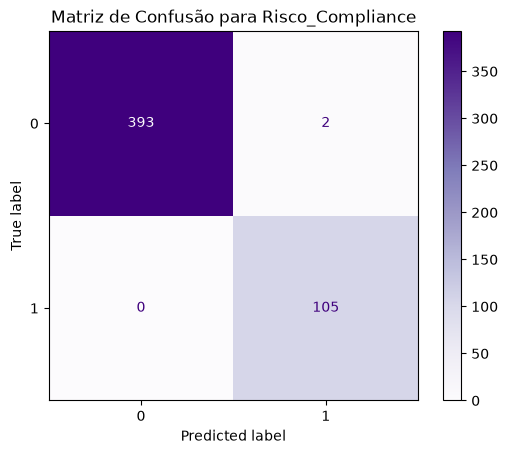

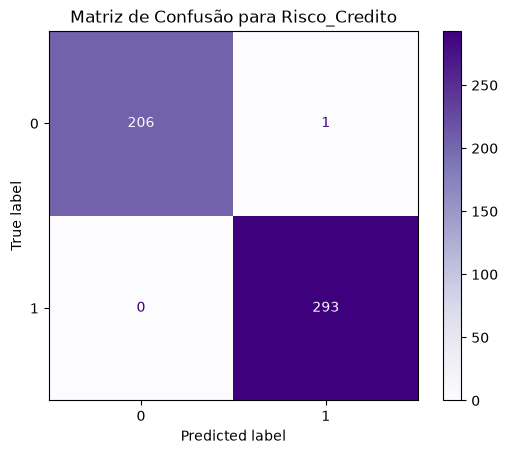

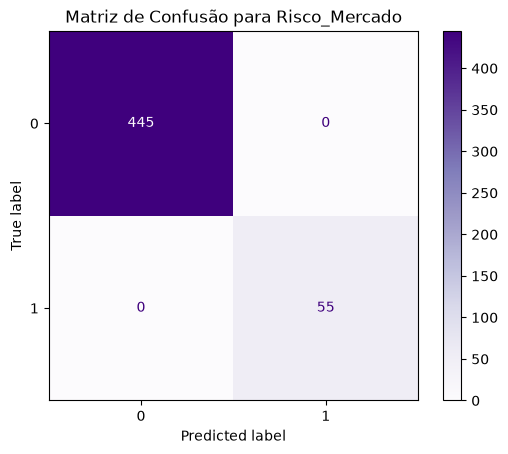

In [382]:
for target in targets:
    conf_matrix = confusion_matrix(y_pred=y_pred[target], y_true=y_test[target]) # y_pred é numpy, y_test é pandas.
    cmd = ConfusionMatrixDisplay(conf_matrix)
    cmd.plot(
      cmap="Purples"
    )
    plt.title(f'Matriz de Confusão para {target}')

### Log Loss por Target
- Log loss é baixo, ou seja o modelo está classificando com confiança.

In [383]:
for target in targets:
    log_loss_score = log_loss(y_proba=y_proba[target], y_true=y_test[target]) # type: ignore
    print(f"{target}: log-loss {log_loss_score}")

Risco_Compliance: log-loss 0.006097576935786863
Risco_Credito: log-loss 0.004171385785727162
Risco_Mercado: log-loss 0.00018713527970304504


## Importância das Features por Target

In [385]:
for i, model in enumerate(models):
    importancias = models[model].feature_importances_
    nomes_features = X.columns.tolist()

    df_importances = pd.DataFrame({ 'feature': nomes_features, 'importance': importancias})
    df_importances.sort_values(by='importance', inplace=True)

    fig = px.bar(
      df_importances,
      x='importance',
      y='feature',
      orientation='h',
      title=f'Importância das 10 principais features para {model}',
      color='importance',
      color_continuous_scale=px.colors.colorbrewer.RdBu_r,
      labels={ 'feature': 'Feature', 'importance': "Importância"}
    )

    fig.update_layout(
        height=600,
    )

    fig.show()

## Visualizar Árvores do Ensemble

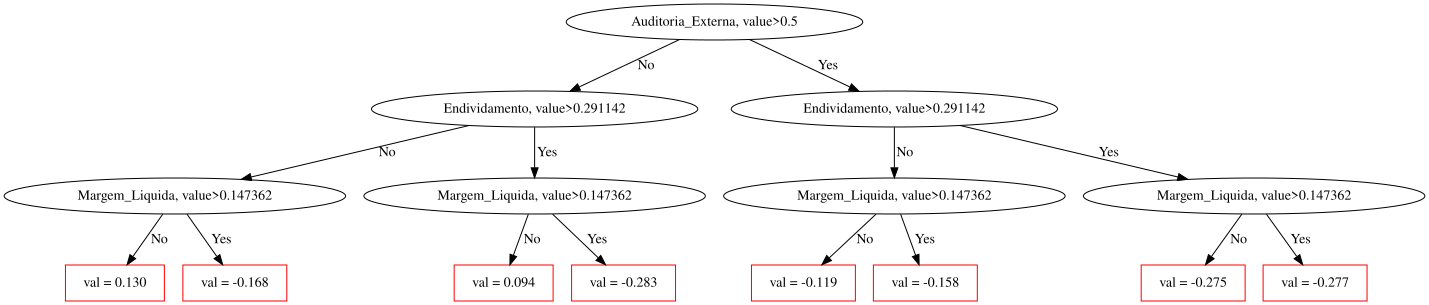

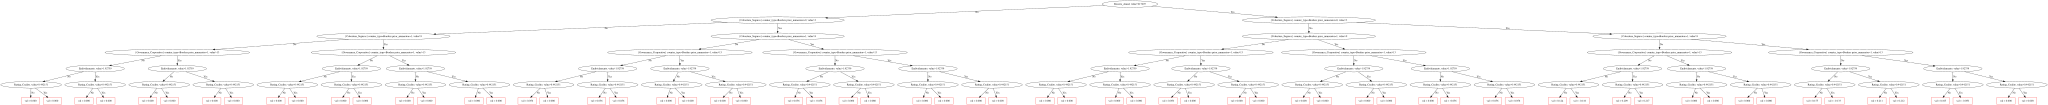

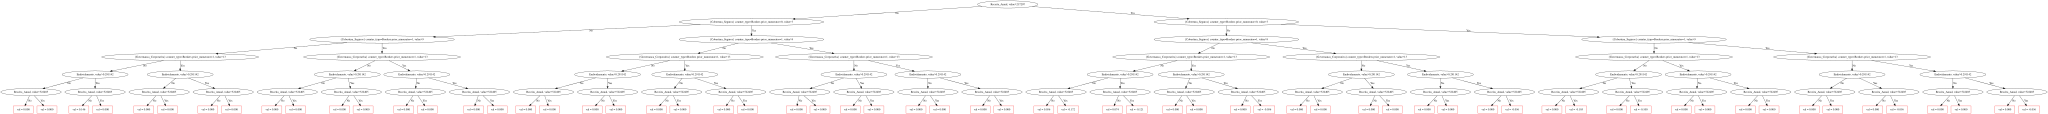

In [394]:
for key in models:
    model = models[key]

    pool = Pool(
      data=X_train,
      label=y_train[key],
      cat_features=cat_cols,
      feature_names=list(X_train.columns)
    )

    tree = model.plot_tree(tree_idx=0, pool=pool)

    display(tree)
    

## Shapley Values

### Obter Shapley Values

In [ ]:
explainers = []
shap_values = []

for i, target in enumerate(targets):
    print(f'Calculando SHAP values para {target}.')

    explainer = shap.TreeExplainer(models[target])

    shap_values_target = explainer.shap_values(X=X_test)

    explainers.append(explainer)
    shap_values.append(shap_values_target)

Calculando SHAP values para Risco_Compliance.
Calculando SHAP values para Risco_Credito.
Calculando SHAP values para Risco_Mercado.


### Plotar Gráficos

Gráfico SHAP para Risco_Compliance.


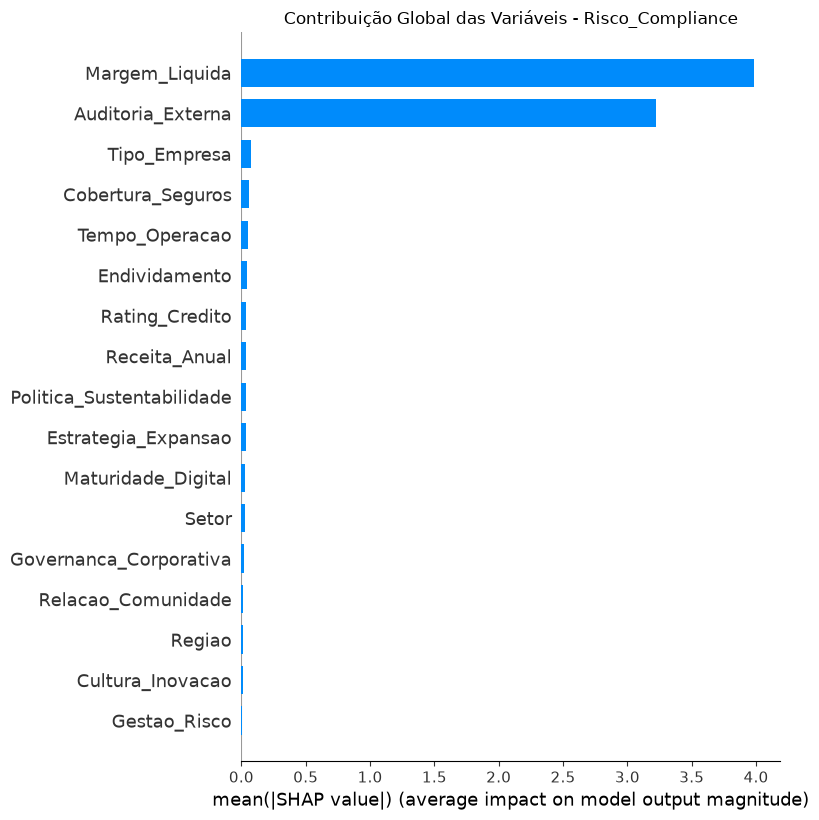

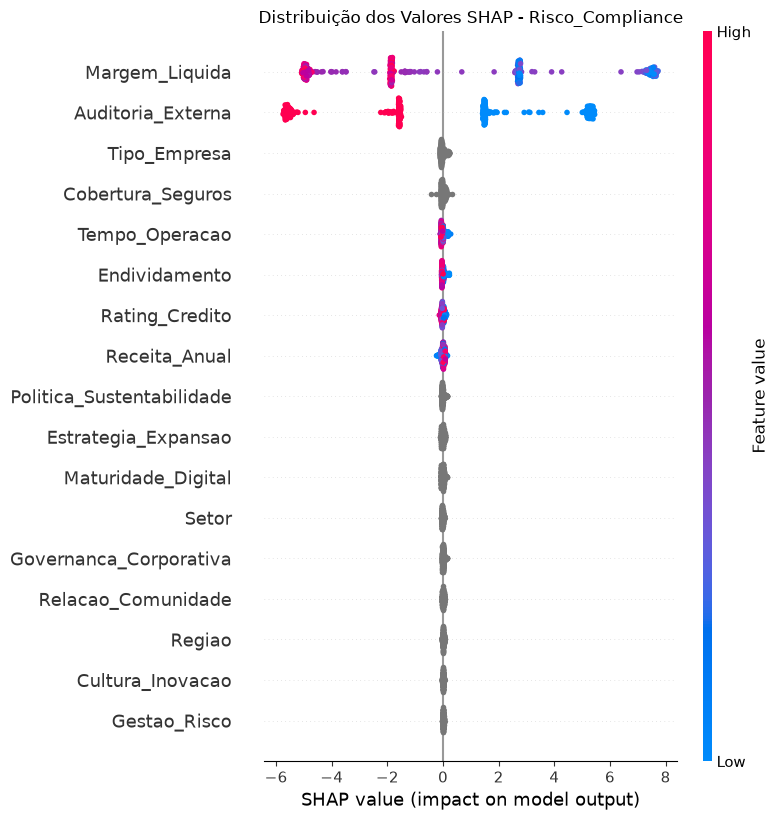

Gráfico SHAP para Risco_Credito.


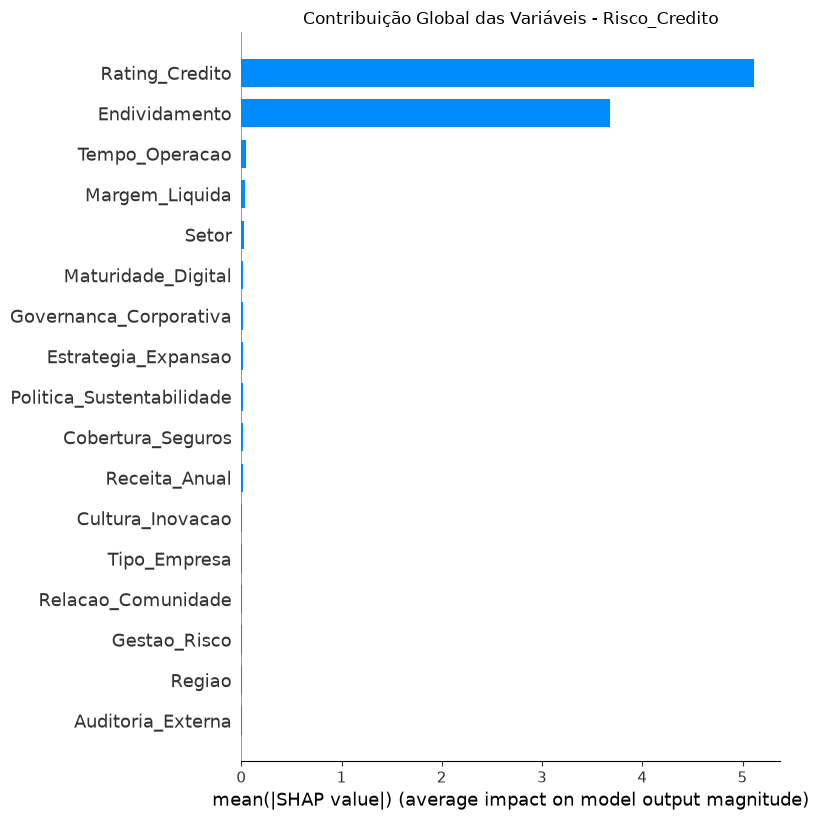

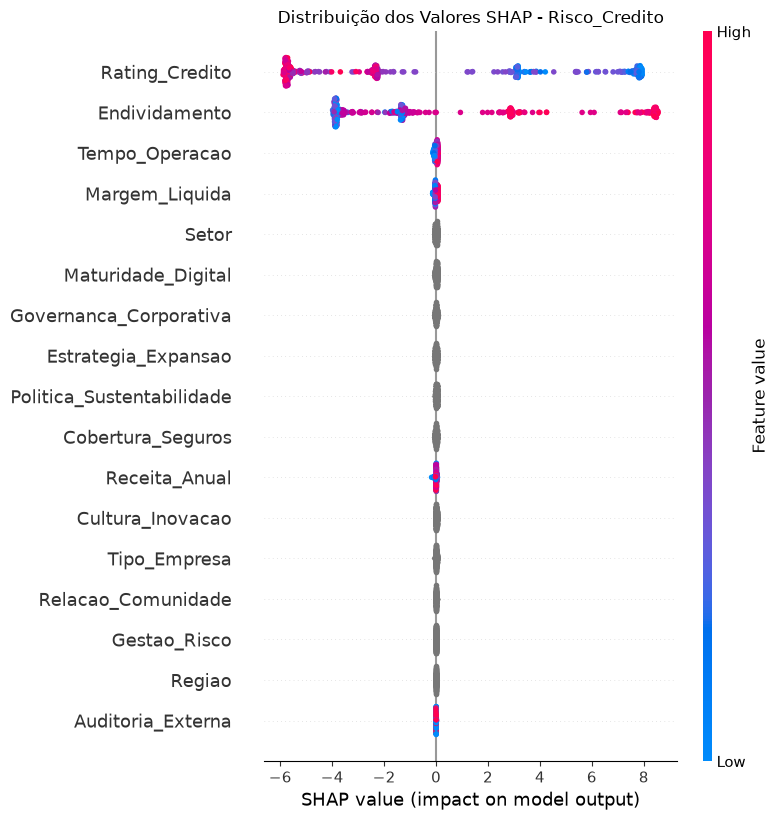

Gráfico SHAP para Risco_Mercado.


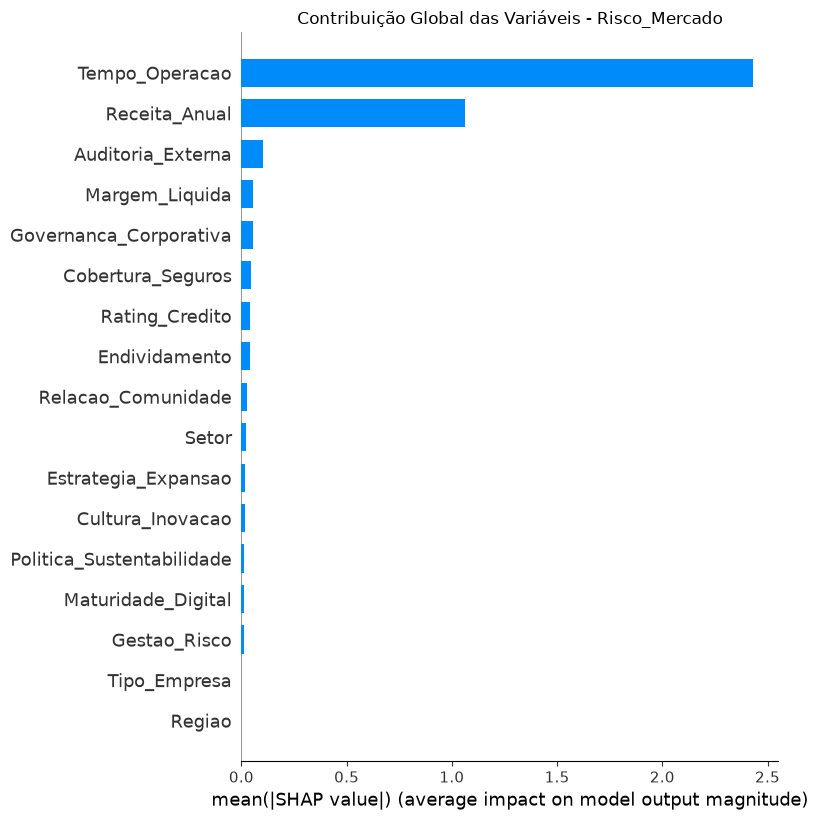

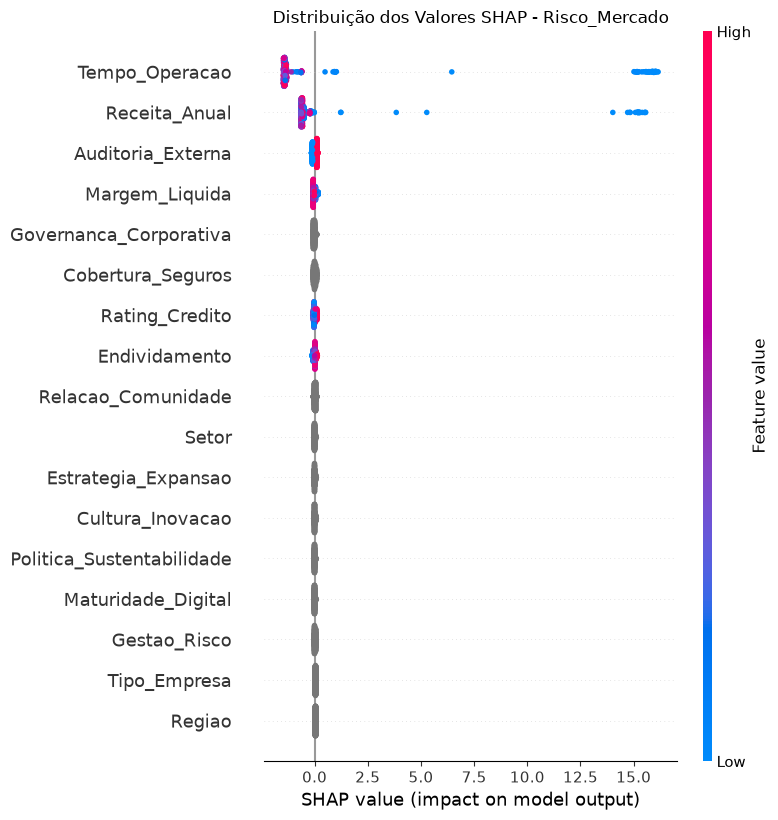

In [401]:
for i, target in enumerate(targets):
    print(f"Gráfico SHAP para {target}.")

    shap.summary_plot(
        shap_values[i],
        X_test,
        plot_type='bar',
        show=False,
    )
    plt.title(f'Contribuição Global das Variáveis - {target}')
    plt.tight_layout()
    plt.show()
    plt.close()

    shap.summary_plot(
      shap_values[i],
      X_test,
      show=False,
    )
    plt.title(f'Distribuição dos Valores SHAP - {target}')
    plt.tight_layout()
    plt.show()
    plt.close()